In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/manutejachindukuru/snatching/snatching_17.mp4
/kaggle/input/datasets/manutejachindukuru/snatching/snatching_18.mp4
/kaggle/input/datasets/manutejachindukuru/snatching/snatching_5.mp4
/kaggle/input/datasets/manutejachindukuru/snatching/snatching_11.mp4
/kaggle/input/datasets/manutejachindukuru/snatching/snatching_6.mp4
/kaggle/input/datasets/manutejachindukuru/snatching/snatching_2.mp4
/kaggle/input/datasets/manutejachindukuru/snatching/snatching_10.mp4
/kaggle/input/datasets/snehasingh3040/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching96.npz
/kaggle/input/datasets/snehasingh3040/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching78.npz
/kaggle/input/datasets/snehasingh3040/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching125.npz
/kaggle/input/datasets/snehasingh3040/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching24.npz
/kaggle/input/datasets/snehasingh3040/chain-snatching-datas

In [2]:
import cv2, os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
import tensorflow as tf

2026-02-23 13:12:17.314134: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771852337.562023      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771852337.634268      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771852338.203774      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771852338.203825      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771852338.203828      17 computation_placer.cc:177] computation placer alr

In [3]:
IMG_SIZE, THRESHOLD = 128, 0.65
snatch_path = "/kaggle/input/chain-snatching-cctv-dataset/Chain_Snatching_Videos"
normal_path = "/kaggle/input/datasets/kipshidze/shoplifting-video-dataset/normal"
test_video  = "/kaggle/input/datasets/lathika04/snaching-videos/snatch1.mp4"

In [4]:
X, y = [], []
def load_videos(folder, label, max_videos=30):
    for video in os.listdir(folder)[:max_videos]:
        cap, count = cv2.VideoCapture(os.path.join(folder, video)), 0
        while cap.isOpened() and count < 10:
            ret, frame = cap.read()
            if not ret: break
            X.append(cv2.resize(frame, (IMG_SIZE, IMG_SIZE)) / 255.0)
            y.append(label)
            count += 1
        cap.release()
load_videos(snatch_path, 1)
load_videos(normal_path, 0)
X, y = np.array(X), np.array(y)
print(f"Total: {len(X)} | Snatching: {sum(y==1)} | Normal: {sum(y==0)}")

Total: 600 | Snatching: 300 | Normal: 300


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = Sequential([
    tf.keras.Input(shape=(128,128,3)),
    Conv2D(32, (3,3), activation='relu'), MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'), MaxPooling2D(2,2),
    Flatten(), Dense(64, activation='relu'), Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

2026-02-23 13:12:49.490373: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 454ms/step - accuracy: 0.7298 - loss: 0.4521 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 421ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 4.3296e-05
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 418ms/step - accuracy: 1.0000 - loss: 1.9286e-05 - val_accuracy: 1.0000 - val_loss: 1.5665e-05
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 433ms/step - accuracy: 1.0000 - loss: 8.0715e-06 - val_accuracy: 1.0000 - val_loss: 8.8961e-06
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 432ms/step - accuracy: 1.0000 - loss: 4.3902e-06 - val_accuracy: 1.0000 - val_loss: 7.7036e-06


In [6]:
event_log = []
cap    = cv2.VideoCapture(test_video)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS) or 25
out    = cv2.VideoWriter('processed_output.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

frame_no = 0
while True:
    ret, frame = cap.read()
    if not ret: break

    prob       = model.predict(np.expand_dims(cv2.resize(frame, (IMG_SIZE,IMG_SIZE)) / 255.0, axis=0), verbose=0)[0][0]
    confidence = round(float(prob) * 100, 2)
    status     = "SNATCHING" if prob > THRESHOLD else "NORMAL"
    color      = (0,0,255) if status == "SNATCHING" else (0,255,0)

    event_log.append({"frame": frame_no, "confidence": confidence, "status": status})
    cv2.putText(frame, f"Confidence: {confidence}%", (20,60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,165,0), 2)
    cv2.putText(frame, f"Status: {status}",          (20,90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color,        2)

    out.write(frame)
    frame_no += 1

cap.release()
out.release()
print(f"Total frames processed: {frame_no}")

Total frames processed: 1054


   frame  confidence     status
0      0       100.0  SNATCHING
1      1       100.0  SNATCHING
2      2       100.0  SNATCHING
3      3       100.0  SNATCHING
4      4       100.0  SNATCHING


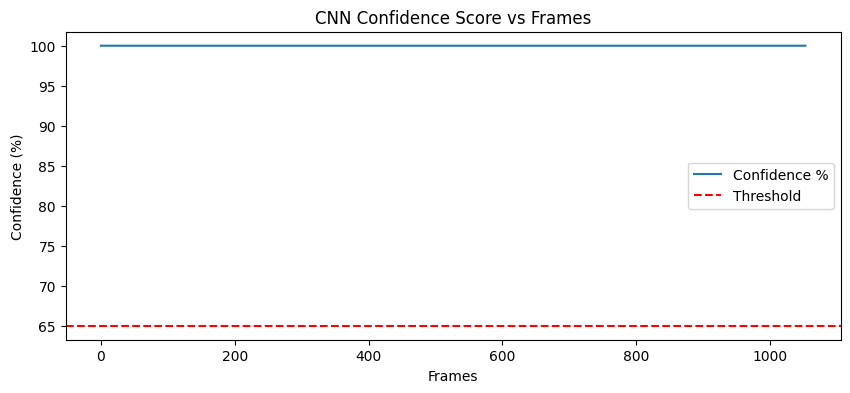

Total Snatching Events: 1054


In [7]:
df = pd.DataFrame(event_log)
df.to_csv("event_logs.csv", index=False)
print(df.head())

plt.figure(figsize=(10,4))
plt.plot(df['confidence'], label="Confidence %")
plt.axhline(y=THRESHOLD*100, linestyle="--", color='red', label="Threshold")
plt.title("CNN Confidence Score vs Frames")
plt.xlabel("Frames"); plt.ylabel("Confidence (%)"); plt.legend(); plt.show()

print("Total Snatching Events:", len(df[df['status']=="SNATCHING"]))

In [8]:
from IPython.display import Video
Video('processed_output.mp4', embed=True)